In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carichiamo l'immagine e creiamo una versione distorta
img_orig = cv2.imread('../images/mosketeers.jpg', cv2.IMREAD_GRAYSCALE)
rows, cols = img_orig.shape

# Trasformazione nota (Omografia)
pts1 = np.float32([[50, 50], [200, 50], [50, 200], [200, 200]])
pts2 = np.float32([[40, 60], [210, 40], [30, 210], [220, 190]])
H_true = cv2.getPerspectiveTransform(pts1, pts2)
img_distorted = cv2.warpPerspective(img_orig, H_true, (cols, rows))

# 2. Estrazione feature (SIFT)
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img_orig, None)
kp2, des2 = sift.detectAndCompute(img_distorted, None)

# 3. Matching + Lowe's ratio test
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

# 4. RANSAC per stimare l'Omografia
src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

In [23]:
#  Decidi quale trasformazione usare
tipo_transform = 'homography'

if tipo_transform == 'homography':
    H_est, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    result = cv2.warpPerspective(img_orig, H_est, (cols, rows))
    
elif tipo_transform == 'affine':
    # La affine è 2x3, quindi serve warpAffine
    H_est, mask = cv2.estimateAffine2D(src_pts, dst_pts, method=cv2.RANSAC, ransacReprojThreshold=5.0)
    result = cv2.warpAffine(img_orig, H_est, (cols, rows))
    
elif tipo_transform == 'partial':
    # La partial affine (rigida + scala) è 2x3, serve warpAffine
    H_est, mask = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.RANSAC, ransacReprojThreshold=5.0)
    result = cv2.warpAffine(img_orig, H_est, (cols, rows))

matchesMask = mask.ravel().tolist()

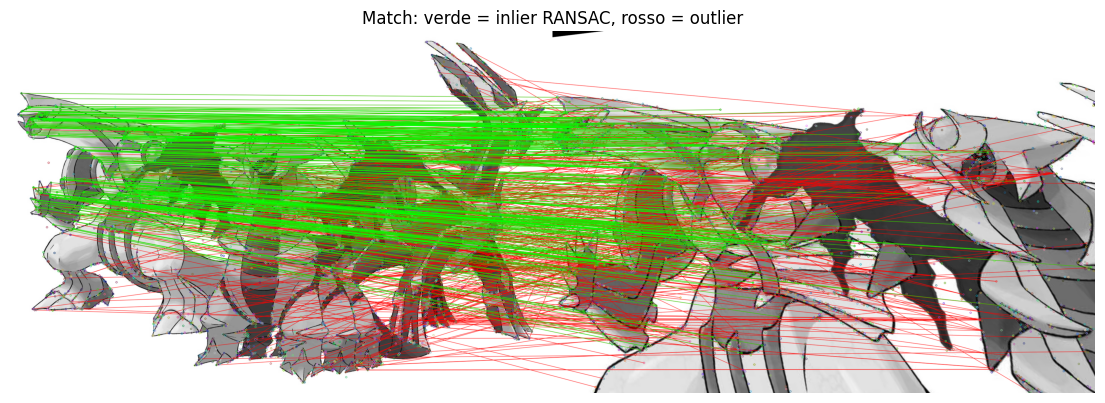

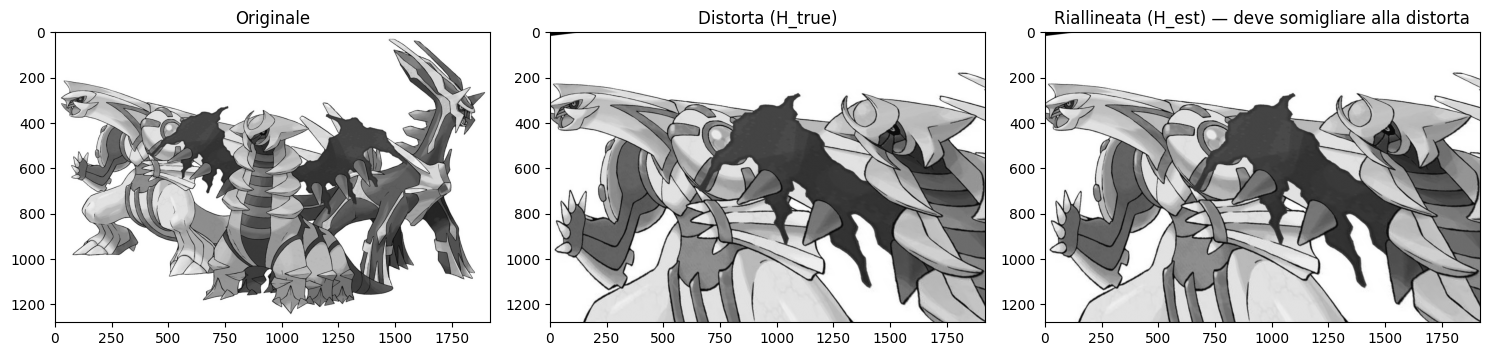

In [24]:
# 5. Visualizzazione stile "inliers/outliers" (come nella tua immagine)
# prima disegniamo TUTTI i match in rosso (saranno gli outlier "di sfondo")
img_matches = cv2.drawMatches(
    img_orig, kp1, img_distorted, kp2, good, None,
    matchColor=(0, 0, 255),      # rosso (BGR) per gli outlier
    singlePointColor=None,
    matchesMask=None,            # disegna tutti i match
    flags=cv2.DrawMatchesFlags_DEFAULT
)

# poi sovrapponiamo in verde SOLO gli inlier
img_matches = cv2.drawMatches(
    img_orig, kp1, img_distorted, kp2, good, img_matches,
    matchColor=(0, 255, 0),      # verde per gli inlier
    singlePointColor=None,
    matchesMask=matchesMask,     # solo gli inlier
    flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG
)

# 6. Confronto tra warping "vero" e warping stimato da RANSAC
if H_est.shape == (3, 3):
    # È una Homography (3x3)
    result = cv2.warpPerspective(img_orig, H_est, (cols, rows))
else:
    # È Affine o Partial Affine (2x3)
    result = cv2.warpAffine(img_orig, H_est, (cols, rows))
    
plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Match: verde = inlier RANSAC, rosso = outlier")
plt.axis('off')
plt.show()

plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(img_orig, 'gray'); plt.title("Originale")
plt.subplot(132); plt.imshow(img_distorted, 'gray'); plt.title("Distorta (H_true)")
plt.subplot(133); plt.imshow(result, 'gray'); plt.title("Riallineata (H_est) — deve somigliare alla distorta")
plt.tight_layout()
plt.show()